# Semana 1 — EDA, baselines y estacionalidad

**Objetivo de aprendizaje.** Reconocer la anatomía de una serie temporal, cuantificar estacionalidad diaria/semanal, construir baselines honestos y demostrar por qué el orden temporal importa.

**Caso de negocio.** Una autoridad vial (p. ej., el corredor I-94 en Minneapolis–Saint Paul) necesita decidir la apertura de carriles, los turnos de operación, los programas de mantenimiento y los planes de contingencia; para ello debe **anticipar el tráfico horario**. Subestimar el volumen puede derivar en congestión, demoras y mayor riesgo de siniestralidad; sobreestimarlo implica recursos ociosos (personal, equipos y carriles reservados). El error del pronóstico tiene, por tanto, un costo asimétrico según la franja horaria.

**Pregunta guía.** ¿Qué tan difícil es este problema si solo uso reglas simples? La responderemos con baselines honestos: si una regla simple (p. ej., "repetir la misma hora de la semana pasada") ya logra errores bajos, cualquier modelo más complejo debe demostrar su valor contra ese piso.

- **Dataset:** `data/01_traffic_metro/traffic.csv`
- **Duración estimada:** 4–5 horas
- **Unidad del target:** vehículos por hora
- **Seed global:** 42

> El repositorio estandarizó `traffic_volume` como `y` y `date_time` como `ds`. El notebook usa los nombres reales del CSV.

**Contrato de secciones:** Sección 0: Configuración y contrato de datos; Sección 1: Análisis previo; Sección 2: Estrategia de validación; Sección 3: Modelado; Sección 4: Análisis posterior; Sección 5: Lecciones metodológicas; Sección 6: Ejercicios.

### 0.1 Imports y reproducibilidad

Todas las funciones propias usan type hints. Se fija la semilla antes de cualquier muestreo.

In [1]:
# Imports estándar, científicos y de forecasting.
from __future__ import annotations
from pathlib import Path
import random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tsa.statespace.tools import diff
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
# Seed global: garantiza reproducibilidad de cualquier muestreo.
SEED = 42
random.seed(SEED); np.random.seed(SEED)
warnings.filterwarnings("ignore")
# Tema visual consistente para todas las gráficas del notebook.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4)

### 0.2 Rutas portables

La ruta se resuelve desde el directorio del repositorio o desde `notebooks/`.

In [2]:
# Rutas candidatas según el directorio desde donde se ejecute el notebook.
CANDIDATES = [Path("data/01_traffic_metro/traffic.csv"), Path("../data/01_traffic_metro/traffic.csv")]
DATA_PATH = next((p for p in CANDIDATES if p.exists()), None)
# Si ninguna ruta existe, el notebook se detiene con un mensaje claro.
assert DATA_PATH is not None, "No se encontró traffic.csv"
print(DATA_PATH.resolve())

/home/enrique/Escritorio/Curso_pronostico_series_temporales/course-timeseries-benchmarks-pro/data/01_traffic_metro/traffic.csv


### 0.3 Carga y schema

Se esperan exactamente 48,204 filas y 9 columnas.

La celda siguiente lee el CSV y valida las dimensiones: se esperan exactamente **48,204 filas y 9 columnas**.

In [3]:
# Lectura del CSV: 'ds' se parsea como datetime; el resto se conserva tal cual.
raw = pd.read_csv(DATA_PATH, parse_dates=["ds"])
# Contrato de dimensiones: 48,204 filas × 9 columnas.
assert raw.shape == (48_204, 9), raw.shape
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   holiday              61 non-null     object        
 1   temp                 48204 non-null  float64       
 2   rain_1h              48204 non-null  float64       
 3   snow_1h              48204 non-null  float64       
 4   clouds_all           48204 non-null  int64         
 5   weather_main         48204 non-null  object        
 6   weather_description  48204 non-null  object        
 7   ds                   48204 non-null  datetime64[ns]
 8   y                    48204 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 3.3+ MB


### 0.4 Caso de negocio: decisiones que dependen del pronóstico

Una autoridad vial que gestiona el corredor I-94 necesita **anticipar el tráfico horario** para tomar decisiones operativas:

- **Apertura de carriles:** habilitar carriles adicionales o reversibles en horas pico.
- **Turnos de operación:** programar personal de peaje, patrullaje y atención de incidentes.
- **Mantenimiento:** planificar cierres y obras en ventanas de bajo tráfico.
- **Contingencias:** activar planes ante eventos (clima, accidentes, obras).

El error del pronóstico tiene un costo **asimétrico**: subestimar el tráfico puede producir congestión, demoras y mayor riesgo de siniestralidad; sobreestimarlo implica recursos ociosos (personal, equipos y carriles reservados). Esta asimetría justifica prestar atención especial a las franjas horarias de mayor volumen (sección 4.8).

**Pregunta guía del notebook:** ¿qué tan difícil es este problema si solo uso reglas simples? La respuesta la darán los baselines de la sección 3.

> **¿Para quién importa este pronóstico?**
> La autoridad vial usa el pronóstico horario del corredor I-94 para decidir cuándo
> habilitar carriles adicionales, cuánto personal de patrullaje e incidentes asignar
> y cuándo activar protocolos de congestión. Subestimar el tráfico un viernes a las
> 18:00 tiene un costo distinto que sobreestimarlo un martes a las 03:00. Este
> notebook construye el piso de honestidad contra el cual toda propuesta futura
> deberá medirse.

> *Este notebook modela volumen de tráfico agregado (vehículos/hora en el corredor),
> no comportamiento individual de conductores. Las conclusiones aplican a decisiones
> de operación de la vía, no a intervenciones sobre conductores específicos.*

### 0.5 Contrato de columnas

El contrato impide continuar si cambió silenciosamente la fuente.

Si el conjunto de columnas cambia, el notebook se detiene: así evitamos continuar con una fuente distinta a la esperada.

In [4]:
# Contrato de columnas: nombres estandarizados por el repositorio.
EXPECTED = {"holiday", "temp", "rain_1h", "snow_1h", "clouds_all", "weather_main", "weather_description", "ds", "y"}
assert set(raw.columns) == EXPECTED
assert pd.api.types.is_datetime64_any_dtype(raw["ds"])
assert pd.api.types.is_numeric_dtype(raw["y"])
# Si el conjunto no coincide, la fuente cambió y conviene detenerse.
print("Contrato de columnas: OK")

Contrato de columnas: OK


### 0.6 Calidad: nulos

Los nulos se reportan por variable antes de cualquier transformación.

Interpretación: `holiday` concentra casi todos los nulos (solo 61 horas etiquetadas como festivo); el resto de variables no tiene ausencias.

In [5]:
# Reporte de nulos por variable antes de transformar.
null_report = raw.isna().sum().to_frame("n_missing")
# Porcentaje de ausencia sobre el total de filas.
null_report["pct"] = 100 * null_report["n_missing"] / len(raw)
null_report

,n_missing,pct
holiday,48143,99.873454
temp,0,0.000000
rain_1h,0,0.000000
snow_1h,0,0.000000
clouds_all,0,0.000000
weather_main,0,0.000000
weather_description,0,0.000000
ds,0,0.000000
y,0,0.000000


### 0.7 Calidad: duplicados

La fuente posee múltiples registros por timestamp cuando hay más de una descripción meteorológica.

Hay 17 filas exactamente duplicadas y 7,629 timestamps repetidos: la fuente registra varias descripciones meteorológicas por hora.

In [6]:
# Duplicados exactos vs. timestamps repetidos: dos problemas distintos.
print("Filas duplicadas exactas:", raw.duplicated().sum())
print("Timestamps duplicados:", raw["ds"].duplicated().sum())
# Muestra de timestamps repetidos con distinta descripción meteorológica.
raw.loc[raw["ds"].duplicated(keep=False)].sort_values("ds").head(8)

Filas duplicadas exactas: 17
Timestamps duplicados: 7629


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,ds,y
178,NaN,281.25,0.0,0.0,99,Rain,light rain,2012-10-10 07:00:00,6793
179,NaN,281.25,0.0,0.0,99,Drizzle,light intensity drizzle,2012-10-10 07:00:00,6793
180,NaN,280.10,0.0,0.0,99,Rain,light rain,2012-10-10 08:00:00,6283
181,NaN,280.10,0.0,0.0,99,Drizzle,light intensity drizzle,2012-10-10 08:00:00,6283
182,NaN,279.61,0.0,0.0,99,Rain,light rain,2012-10-10 09:00:00,5680
183,NaN,279.61,0.0,0.0,99,Drizzle,light intensity drizzle,2012-10-10 09:00:00,5680
269,NaN,282.43,0.0,0.0,57,Drizzle,light intensity drizzle,2012-10-14 09:00:00,2685
270,NaN,282.43,0.0,0.0,57,Mist,mist,2012-10-14 09:00:00,2685


### 0.8 Rango temporal

La frecuencia nominal es horaria, pero no todos los timestamps aparecen.

El rango va de 2012-10-02 09:00 a 2018-09-30 23:00, con 40,575 timestamps únicos; la frecuencia nominal es horaria.

In [7]:
# Rango temporal del dataset (seis años de datos horarios).
print("Inicio:", raw.ds.min())
print("Fin:", raw.ds.max())
print("Timestamps únicos:", raw.ds.nunique())

Inicio: 2012-10-02 09:00:00
Fin: 2018-09-30 23:00:00
Timestamps únicos: 40575


### 0.9 Auditoría de gaps

Se compara el índice observado con una rejilla horaria completa.

La auditoría cuantifica las horas ausentes respecto a una rejilla horaria completa: 11,976 horas faltantes. Este gap es el origen del riesgo *168 filas ≠ 168 horas*.

**Hueco dominante.** El bloque ausente más largo abarca ~10 meses (2014-08-08 → 2015-06-11). Por eso la serie completa muestra un vacío que se lleva casi la mitad de 2015: **no es un error de lectura**, los datos simplemente no existen en la fuente.


In [8]:
# Rejilla horaria completa entre el primer y último timestamp.
full_index = pd.date_range(raw.ds.min().floor("h"), raw.ds.max().floor("h"), freq="h")
observed_index = pd.DatetimeIndex(raw.ds.unique())
# Gaps = horas esperadas que no aparecen en los datos observados.
missing_hours = full_index.difference(observed_index)
print("Horas esperadas:", len(full_index), "Horas faltantes:", len(missing_hours))
# Hueco más largo: bloque contiguo de horas ausentes (el vacío visible en la serie).
block = (missing_hours.to_series().diff() != pd.Timedelta(hours=1)).cumsum()
gaps = missing_hours.to_series().groupby(block).agg(["min", "max", "count"])
longest = gaps.loc[gaps["count"].idxmax()]
print(f"Hueco más largo: {longest['count']:.0f} horas ({longest['min']} → {longest['max']})")
missing_hours[:10]

Horas esperadas: 52551 Horas faltantes: 11976
Hueco más largo: 7386 horas (2014-08-08 02:00:00 → 2015-06-11 19:00:00)


DatetimeIndex(['2012-10-03 07:00:00', '2012-10-03 10:00:00',
               '2012-10-03 11:00:00', '2012-10-03 17:00:00',
               '2012-10-05 02:00:00', '2012-10-05 04:00:00',
               '2012-10-06 03:00:00', '2012-10-07 01:00:00',
               '2012-10-07 02:00:00', '2012-10-09 03:00:00'],
              dtype='datetime64[ns]', freq=None)

### 0.10 Consolidación por hora

Para forecasting univariado se crea una serie única. `y` se promedia si el mismo timestamp aparece con descripciones meteorológicas múltiples; las continuas se promedian y las categóricas toman la primera observación.

Tras la consolidación tendremos un único valor de `y` por timestamp: la base del análisis univariado.

In [9]:
# Variables continuas se promedian; las categóricas toman el primer valor.
num_cols = ["y", "temp", "rain_1h", "snow_1h", "clouds_all"]
cat_cols = ["holiday", "weather_main", "weather_description"]
agg = {**{x: "mean" for x in num_cols}, **{x: "first" for x in cat_cols}}
# Consolidación: un valor por timestamp (índice único horario).
hourly_observed = raw.sort_values("ds").groupby("ds", as_index=True).agg(agg).sort_index()
# Garantía: índice sin duplicados antes de modelar.
assert hourly_observed.index.is_unique
hourly_observed.shape

(40575, 8)

### 0.11 Serie regular para herramientas clásicas

STL/ACF requieren rejilla regular. Solo para EDA, se reindexa e interpola `y` por tiempo. Los modelos/evaluación usarán puntos observados para no puntuar valores fabricados.

La interpolación (`y_eda`) es **solo diagnóstica** (STL/ACF); los modelos y las métricas usarán los valores observados.

In [10]:
# Reindexado a la rejilla completa; los gaps quedan como NaN.
hourly = hourly_observed.reindex(full_index)
hourly.index.name = "ds"
# Marca de observación real: útil para no puntuar valores interpolados.
hourly["y_observed"] = hourly["y"].notna()
# Interpolación temporal solo para EDA/STL, no para evaluar modelos.
hourly["y_eda"] = hourly["y"].interpolate(method="time").ffill().bfill()
print(hourly[["y", "y_eda"]].isna().sum())

y        11976
y_eda        0
dtype: int64


### 0.12 Resumen del target

Estadísticos descriptivos sobre observaciones originales consolidadas.

El target oscila entre 0 y 7,280 vehículos/h, con mediana ≈ 3,427; la cola derecha refleja las horas pico.

In [11]:
# Estadísticos descriptivos del target sobre observaciones consolidadas.
hourly_observed["y"].describe(percentiles=[.01,.25,.5,.75,.99]).to_frame().T

,count,mean,std,min,1%,25%,50%,75%,99%,max
y,40575.0,3290.650474,1984.772909,0.0,259.0,1248.5,3427.0,4952.0,6713.0,7280.0


### 0.13 Visualización completa

La gráfica debe leerse como una secuencia, no como puntos independientes.

Lea la gráfica como una secuencia, no como puntos independientes: el orden temporal es información.

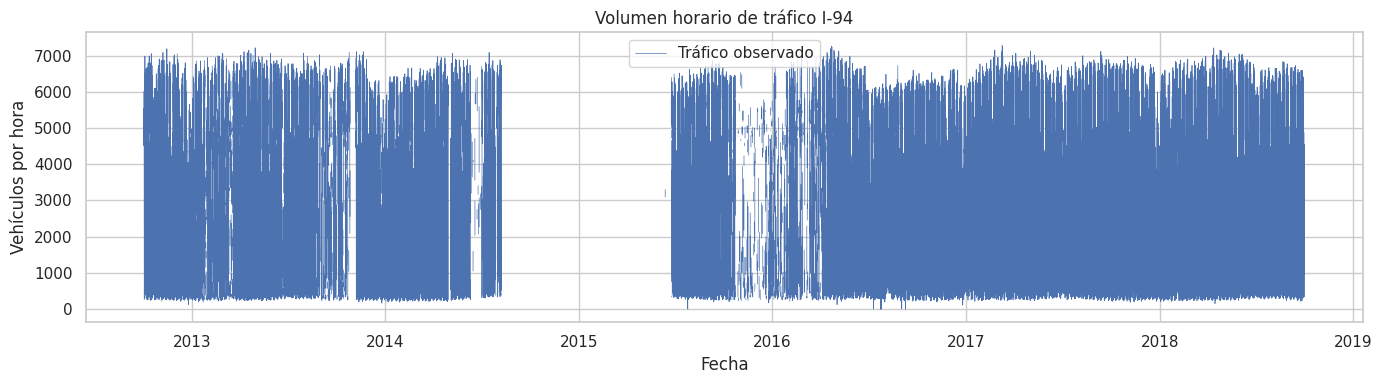

In [12]:
# Serie completa: la estacionalidad domina visualmente.
# Se grafica sobre la rejilla completa (hourly): los gaps quedan como NaN y se
# muestran como vacíos reales, sin líneas rectas que conecten puntos lejanos.
fig, ax = plt.subplots(figsize=(14,4))
ax.plot(hourly.index, hourly.y, lw=.5, label="Tráfico observado")
ax.set(title="Volumen horario de tráfico I-94", xlabel="Fecha", ylabel="Vehículos por hora")
ax.legend(); plt.tight_layout(); plt.show()

## 1. Análisis previo (pre-modeling)

Se examinan tendencia, estacionalidad, estacionariedad, autocorrelación, outliers y cambios estructurales antes de elegir modelos.

### 1.1 Ventana de cuatro semanas

Un zoom revela ciclos diarios y semanales ocultos en la serie completa.

Al hacer zoom se distinguen el ciclo diario (doble pico laboral) y el descenso del fin de semana.

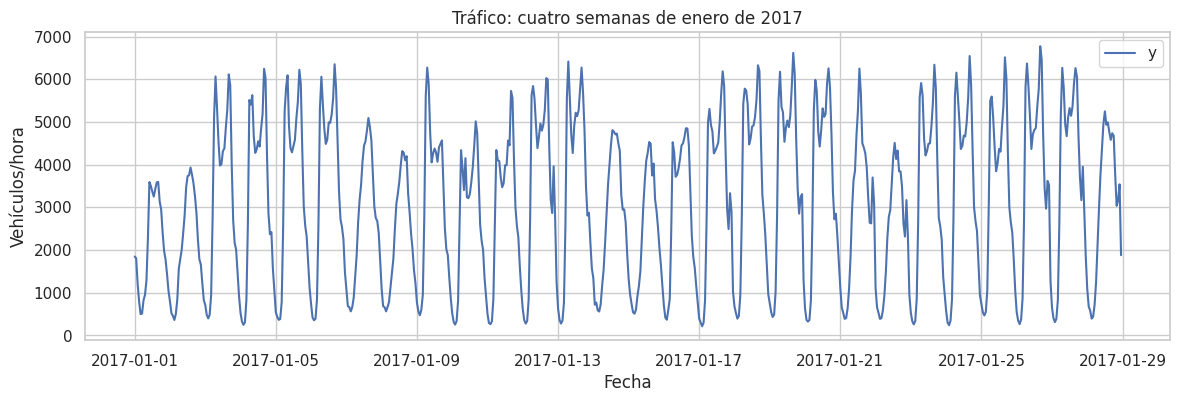

In [13]:
# Zoom de cuatro semanas para ver ciclos diarios y semanales.
sample = hourly_observed.loc["2017-01-01":"2017-01-28"]
fig, ax = plt.subplots(figsize=(14,4)); ax.plot(sample.index, sample.y, label="y")
ax.set(title="Tráfico: cuatro semanas de enero de 2017", xlabel="Fecha", ylabel="Vehículos/hora"); ax.legend(); plt.show()

### 1.2 Tendencia mensual

La mediana mensual es robusta frente a picos y gaps.

La mediana mensual muestra la tendencia de largo plazo y su estacionalidad anual; útil para decidir si diferenciar.

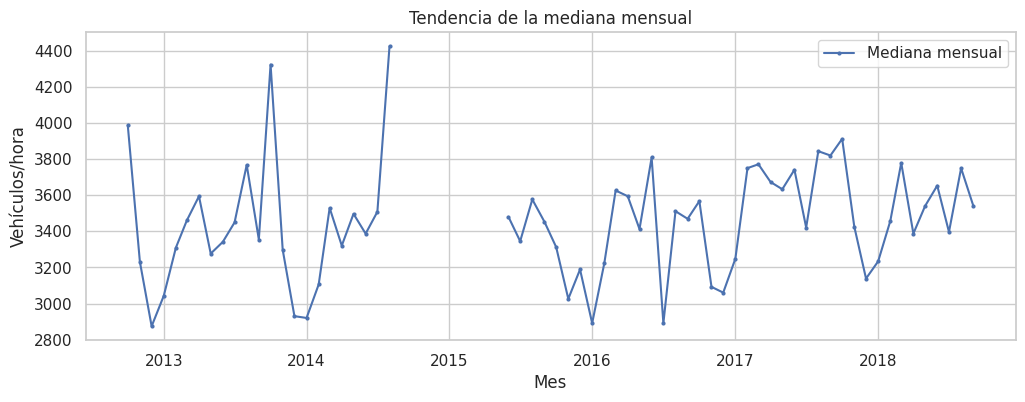

In [14]:
# Mediana mensual robusta a picos; revela la tendencia de largo plazo.
monthly = hourly_observed.y.resample("MS").median()
fig, ax=plt.subplots(); ax.plot(monthly.index, monthly, marker="o", ms=2, label="Mediana mensual")
ax.set(title="Tendencia de la mediana mensual", xlabel="Mes", ylabel="Vehículos/hora"); ax.legend(); plt.show()

### 1.3 Perfil por hora

Se visualiza distribución, no solo media.

El boxplot por hora revela la forma de la distribución (no solo la media): picos en horas laborales y cola en horas altas.

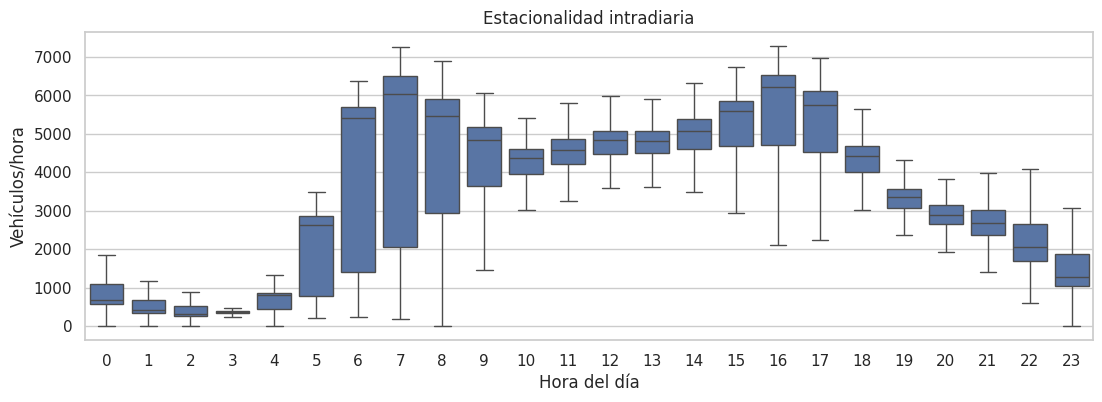

In [15]:
# Distribución por hora: picos matutino y vespertino en días laborables.
tmp=hourly_observed.assign(hour=hourly_observed.index.hour)
fig, ax=plt.subplots(figsize=(13,4)); sns.boxplot(data=tmp,x="hour",y="y",showfliers=False,ax=ax)
ax.set(title="Estacionalidad intradiaria",xlabel="Hora del día",ylabel="Vehículos/hora"); plt.show()

### 1.4 Perfil por día de semana

0 corresponde a lunes y 6 a domingo.

Sábado y domingo presentan menor volumen: el calendario laboral es una feature clave para cualquier modelo.

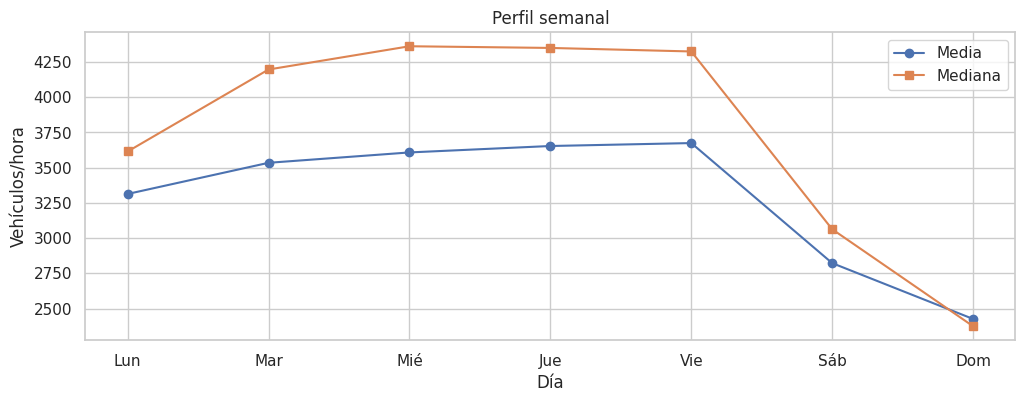

In [16]:
# Perfil semanal: fin de semana con menor volumen.
names=["Lun","Mar","Mié","Jue","Vie","Sáb","Dom"]
tmp=hourly_observed.assign(weekday=hourly_observed.index.dayofweek)
prof=tmp.groupby("weekday").y.agg(["mean","median"])
fig, ax=plt.subplots(); ax.plot(names,prof["mean"],marker="o",label="Media"); ax.plot(names,prof["median"],marker="s",label="Mediana")
ax.set(title="Perfil semanal",xlabel="Día",ylabel="Vehículos/hora"); ax.legend(); plt.show()

### 1.5 Perfil mensual

El mes combina clima, vacaciones y cambios de luz.

La distribución mensual mezcla clima, vacaciones y cambios de luz; conviene interpretarla con cautela.

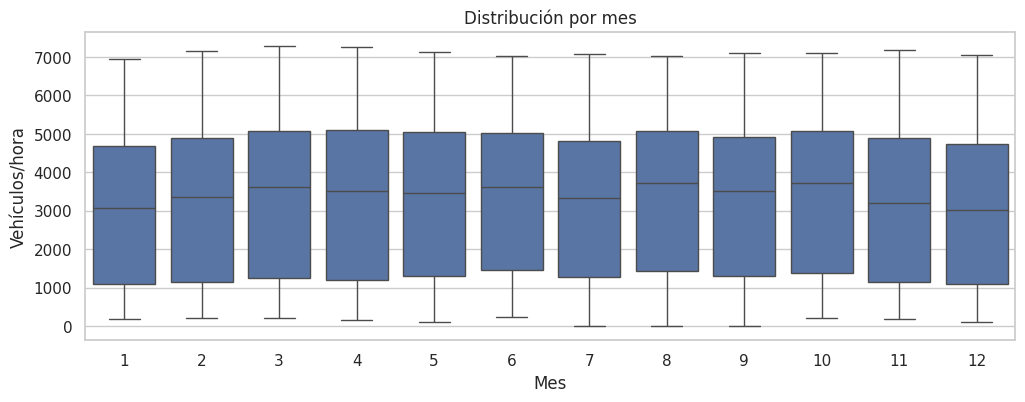

In [17]:
# Distribución mensual: estacionalidad anual (clima, vacaciones, luz).
tmp=hourly_observed.assign(month=hourly_observed.index.month)
fig, ax=plt.subplots(); sns.boxplot(data=tmp,x="month",y="y",showfliers=False,ax=ax)
ax.set(title="Distribución por mes",xlabel="Mes",ylabel="Vehículos/hora"); plt.show()

### 1.6 Heatmap hora × día

La interacción semanal permite detectar horas pico laborables.

El heatmap sintetiza la interacción hora × día: es la justificación empírica del seasonal naive 168.

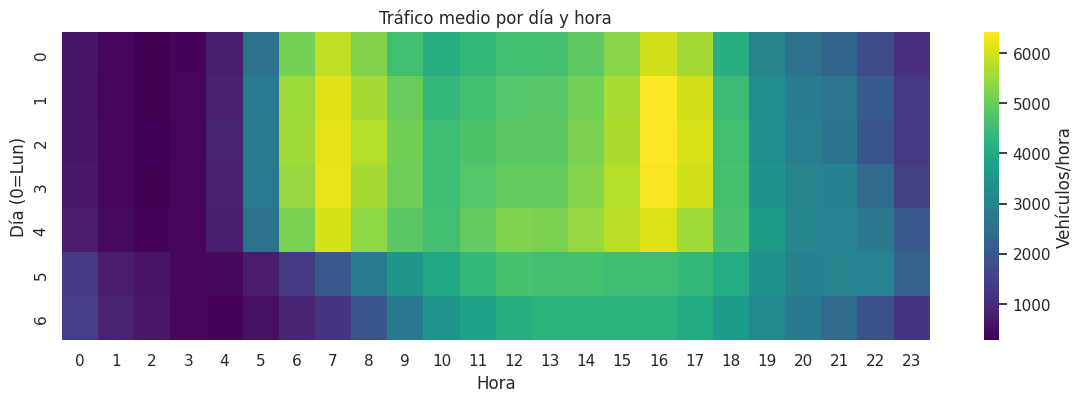

In [18]:
# Interacción hora × día: base empírica del patrón semanal.
grid=(hourly_observed.assign(hour=hourly_observed.index.hour,weekday=hourly_observed.index.dayofweek)
      .pivot_table(index="weekday",columns="hour",values="y",aggfunc="mean"))
fig,ax=plt.subplots(figsize=(14,4)); sns.heatmap(grid,ax=ax,cmap="viridis",cbar_kws={"label":"Vehículos/hora"})
ax.set(title="Tráfico medio por día y hora",xlabel="Hora",ylabel="Día (0=Lun)"); plt.show()

### 1.7 STL semanal

STL con periodo 168 separa tendencia, ciclo semanal y residuo. Se usa la serie regular interpolada solo para diagnóstico.

La descomposición separa tendencia, estacionalidad semanal y residuo; la componente estacional domina la variabilidad.

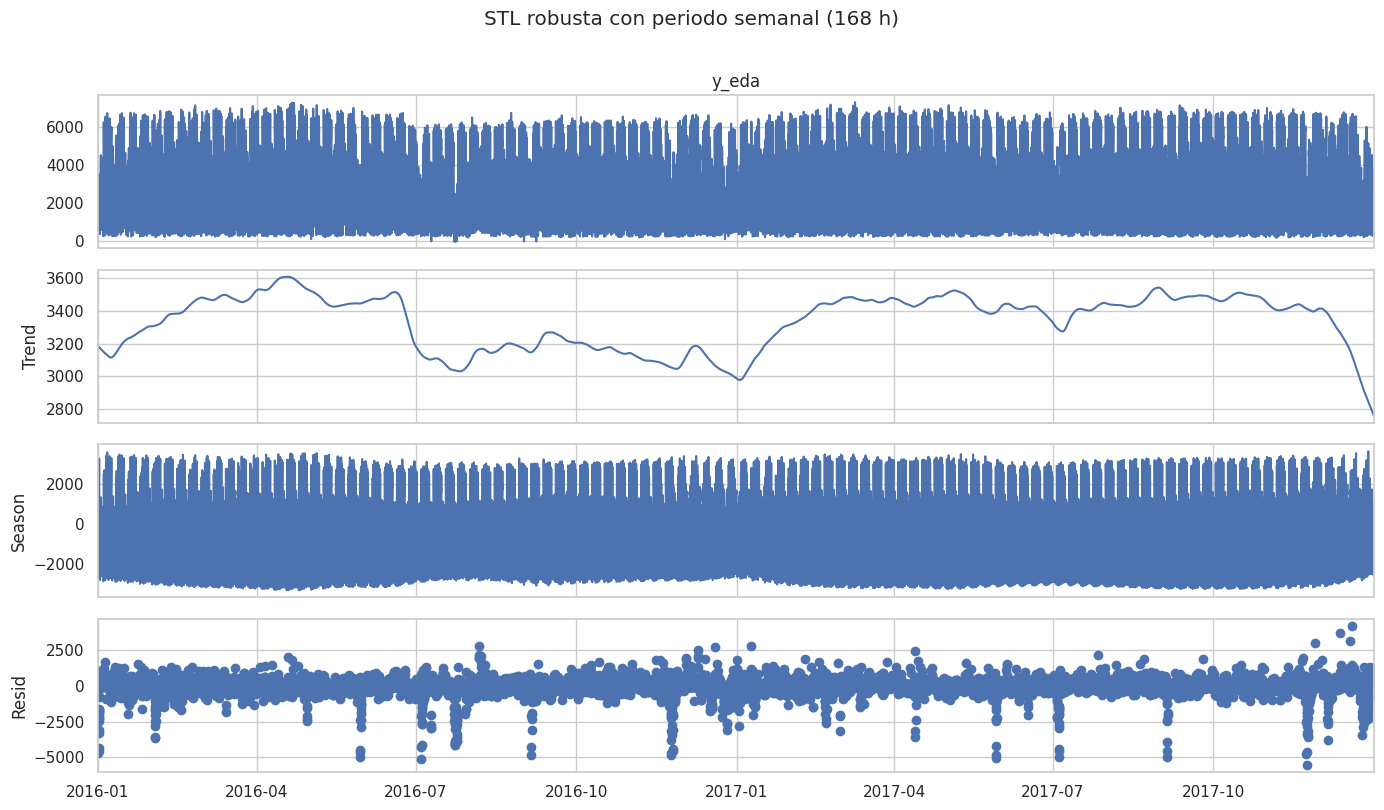

In [19]:
# Ventana de dos años para STL (periodo semanal 168 h).
stl_window = hourly.loc["2016-01-01":"2017-12-31","y_eda"]
# Descomposición robusta: tendencia + estacionalidad semanal + residuo.
stl = STL(stl_window, period=168, robust=True).fit()
fig=stl.plot(); fig.set_size_inches(14,8); fig.suptitle("STL robusta con periodo semanal (168 h)",y=1.01); plt.tight_layout(); plt.show()

### 1.8 Lectura de la descomposición STL

Cómo interpretar la gráfica anterior:

- **Tendencia (trend):** crecimiento sostenido con una meseta hacia el final; el nivel de tráfico no es constante en el tiempo.
- **Estacionalidad semanal (seasonal):** oscilación regular de amplitud grande; es la fuente dominante de variabilidad y la justificación empírica del seasonal naive 168.
- **Residuo (remainder):** ruido alrededor del patrón, con picos puntuales que delatan eventos (clima, incidentes) y que se analizarán como outliers.

Conclusión preliminar: la mayor parte de la variabilidad es predecible por calendario; el residuo es comparativamente pequeño.

### 1.9 Tests de estacionariedad

- **ADF H₀:** la serie tiene raíz unitaria. Se rechaza si *p* < 0.05.
- **KPSS H₀:** la serie es estacionaria alrededor de una constante. Se rechaza si *p* < 0.05.

Los tests responden hipótesis distintas y pueden discrepar en series estacionales o muy largas.

ADF rechaza raíz unitaria en nivel, pero KPSS rechaza estacionariedad: la serie no es estacionaria en sentido estricto; la estacionalidad semanal explica la discrepancia.

### 1.10 Función de reporte de tests

Se reportan estadístico, p-value y decisión con α=0.05.

La función devuelve estadístico, p-value y decisión para ambos tests, con α=0.05.

In [20]:
# Función reutilizable: ADF y KPSS con decisión a α=0.05.
def stationarity_report(x: pd.Series, label: str, alpha: float=0.05) -> pd.DataFrame:
    x=x.dropna().astype(float)
    adf_stat,adf_p,*_=adfuller(x,autolag="AIC")
    kpss_stat,kpss_p,*_=kpss(x,regression="c",nlags="auto")
    return pd.DataFrame([
        {"test":"ADF","series":label,"H0":"raíz unitaria","stat":adf_stat,"p_value":adf_p,"decision":"rechazar H0" if adf_p<alpha else "no rechazar H0"},
        {"test":"KPSS","series":label,"H0":"estacionaria","stat":kpss_stat,"p_value":kpss_p,"decision":"rechazar H0" if kpss_p<alpha else "no rechazar H0"}])
stationarity_report(stl_window,"nivel")

,test,series,H0,stat,p_value,decision
0,ADF,nivel,raíz unitaria,-15.683236,1.463974e-28,rechazar H0
1,KPSS,nivel,estacionaria,0.996282,1.000000e-02,rechazar H0


### 1.11 Diferencia semanal

La diferencia yₜ−yₜ₋₁₆₈ elimina gran parte del patrón semanal.

Tras diferenciar con lag 168, ambos tests coinciden en estacionariedad: la estacionalidad semanal era la principal fuente de no estacionariedad.

In [21]:
# Diferencia semanal yₜ − yₜ₋₁₆₈: elimina gran parte de la estacionalidad.
weekly_diff=stl_window.diff(168).dropna()
stationarity_report(weekly_diff,"diferencia semanal")

,test,series,H0,stat,p_value,decision
0,ADF,diferencia semanal,raíz unitaria,-15.977860,6.888344e-29,rechazar H0
1,KPSS,diferencia semanal,estacionaria,0.108021,1.000000e-01,no rechazar H0


### 1.12 ACF

Picos en 24 y 168 cuantifican memoria diaria/semanal.

Picos en lags 24 y 168 cuantifican la memoria diaria y semanal de la serie.

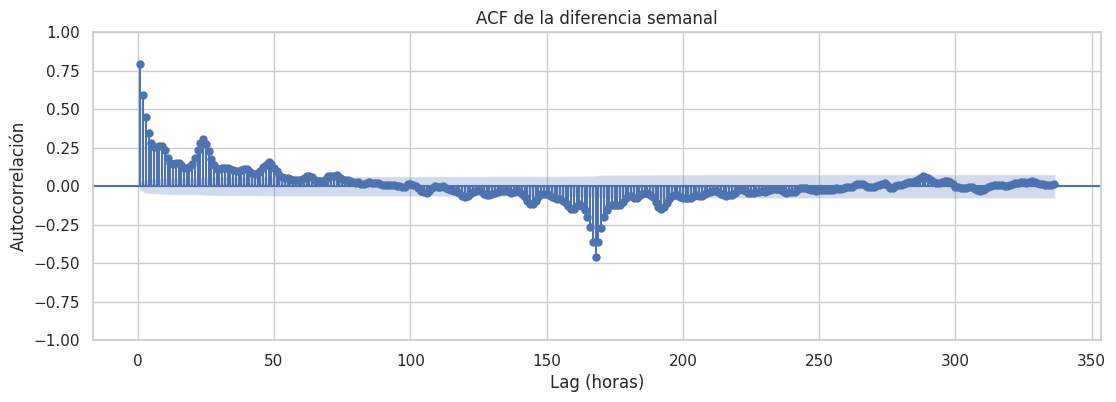

In [22]:
# ACF sobre la diferencia semanal: picos en 24 y 168 confirman memoria.
fig,ax=plt.subplots(figsize=(13,4)); plot_acf(weekly_diff.iloc[-6000:],lags=336,ax=ax,zero=False)
ax.set(title="ACF de la diferencia semanal",xlabel="Lag (horas)",ylabel="Autocorrelación"); plt.show()

### 1.13 PACF

PACF se limita a 72 lags para una lectura estable.

La PACF muestra qué rezagos aportan información una vez controlados los anteriores.

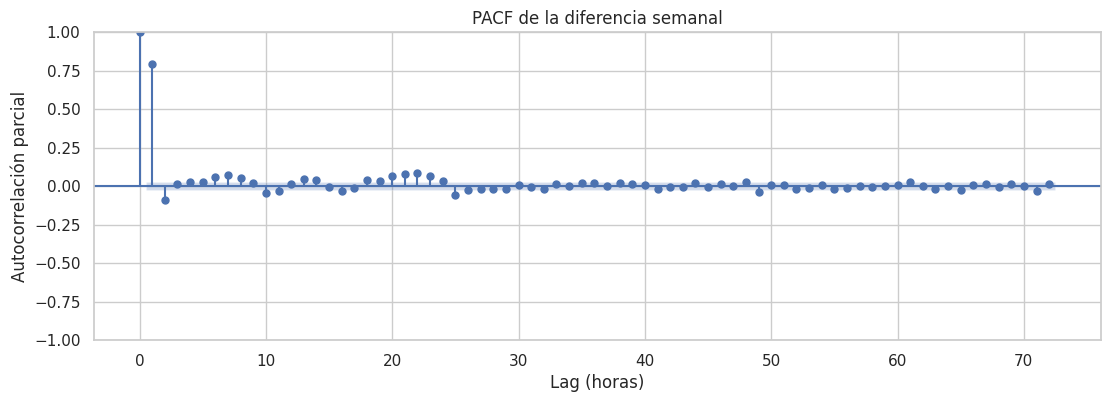

In [23]:
# PACF: identifica rezagos con efecto directo sobre la serie.
fig,ax=plt.subplots(figsize=(13,4)); plot_pacf(weekly_diff.iloc[-6000:],lags=72,ax=ax,method="ywm")
ax.set(title="PACF de la diferencia semanal",xlabel="Lag (horas)",ylabel="Autocorrelación parcial"); plt.show()

### 1.14 Outliers robustos

Se usa MAD sobre el residuo STL; |z robusto| > 4.5 marca candidatos, no errores automáticos.

Los candidatos son puntos a investigar (clima, incidentes), no errores que deban eliminarse automáticamente.

Candidatos: 2121 de 17544


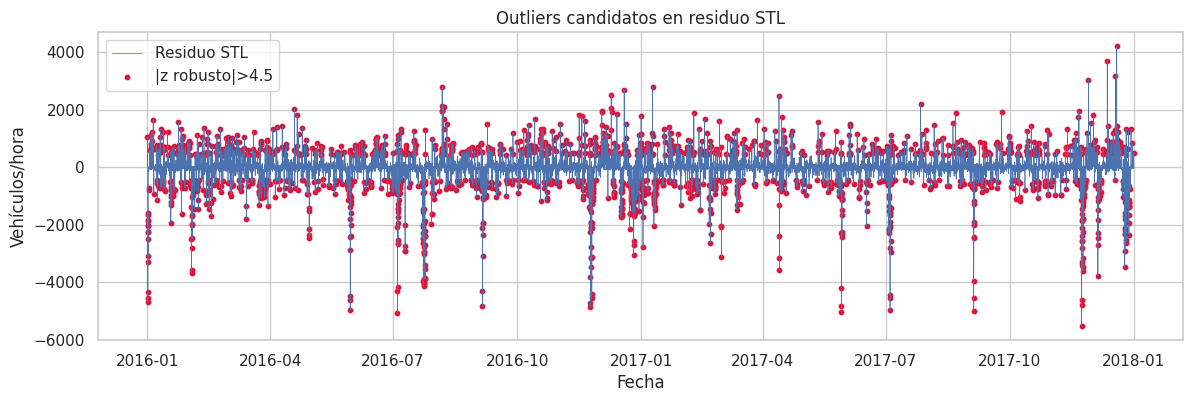

In [24]:
# z robusto basado en MAD: marca candidatos, no errores automáticos.
med=np.median(stl.resid); mad=np.median(np.abs(stl.resid-med)); robust_z=.6745*(stl.resid-med)/mad
outliers=stl.resid[np.abs(robust_z)>4.5]
print("Candidatos:",len(outliers),"de",len(stl.resid))
fig,ax=plt.subplots(figsize=(14,4)); ax.plot(stl.resid.index,stl.resid,lw=.5,label="Residuo STL"); ax.scatter(outliers.index,outliers,color="crimson",s=10,label="|z robusto|>4.5")
ax.set(title="Outliers candidatos en residuo STL",xlabel="Fecha",ylabel="Vehículos/hora"); ax.legend(); plt.show()

### 1.15 CUSUM descriptivo

CUSUM estandarizado ayuda a localizar cambios persistentes; no se interpreta como causalidad.

El CUSUM acumula desviaciones; un quiebre sostenido sugiere un cambio de nivel en la serie.

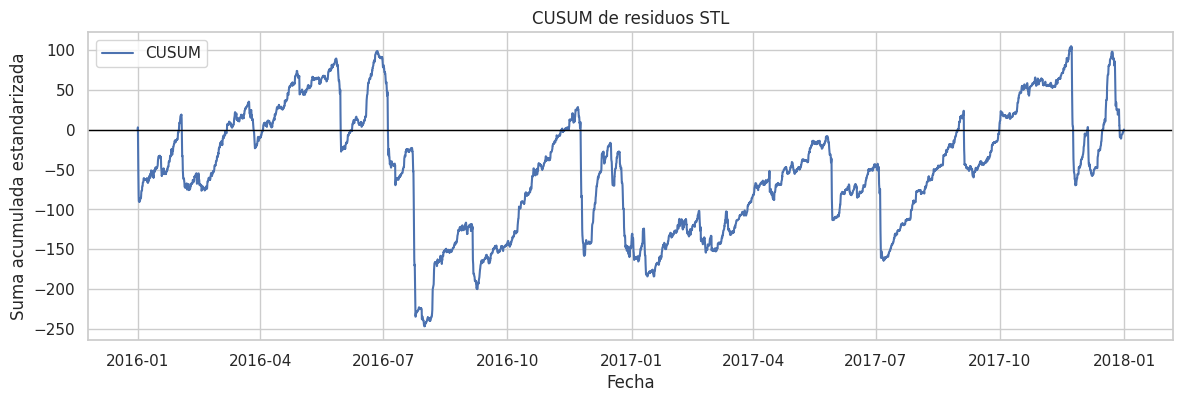

In [25]:
# CUSUM: acumula desviaciones para detectar cambios de nivel.
resid_std=(stl.resid-stl.resid.mean())/stl.resid.std(ddof=1); cusum=resid_std.cumsum()
fig,ax=plt.subplots(figsize=(14,4)); ax.plot(cusum.index,cusum,label="CUSUM")
ax.axhline(0,color="black",lw=1); ax.set(title="CUSUM de residuos STL",xlabel="Fecha",ylabel="Suma acumulada estandarizada"); ax.legend(); plt.show()

### 1.16 Cambio estructural aproximado

El punto con mayor desviación absoluta del CUSUM es un candidato a investigar.

El punto de máxima desviación (2016-07-31 15:00) es un candidato a investigar, no una conclusión causal.

Un cambio en el volumen de tráfico puede deberse a obras viales, eventos, cambios de tarifa o variaciones estacionales no capturadas. Este análisis identifica *dónde* mirar, no *por qué* ocurrió.

In [26]:
# Punto con mayor desviación acumulada: candidato a cambio estructural.
change_candidate=cusum.abs().idxmax()
print("Candidato de cambio estructural:",change_candidate,"CUSUM=",float(cusum.loc[change_candidate]))

Candidato de cambio estructural: 2016-07-31 15:00:00 CUSUM= -246.47949592568142


### 1.17 Covariables

Las correlaciones son descriptivas. Clima y tráfico comparten calendario; no se interpretan causalmente.

Las covariables (clima y calendario) se exploran de forma descriptiva; el clima futuro no se conoce en despliegue.

### 1.18 Correlaciones numéricas

Spearman es robusta a relaciones monotónicas no lineales.

Spearman cuantifica asociaciones monótonas; valores bajos no implican que el clima sea inútil, solo que su señal es débil frente a la estacionalidad.

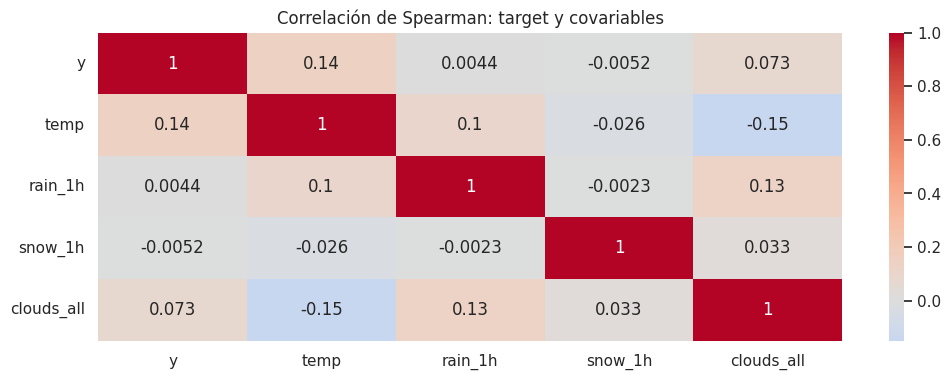

In [27]:
# Correlación de Spearman entre target y covariables (descriptiva).
numeric=["y","temp","rain_1h","snow_1h","clouds_all"]
corr=hourly_observed[numeric].corr(method="spearman")
fig,ax=plt.subplots(); sns.heatmap(corr,annot=True,cmap="coolwarm",center=0,ax=ax)
ax.set(title="Correlación de Spearman: target y covariables"); plt.show()

### 1.19 Correlación cruzada

Se desplaza temperatura para explorar precedencia. Correlación no implica disponibilidad futura.

La correlación cruzada con temperatura desplazada sugiere precedencia, pero no disponibilidad futura de la covariable.

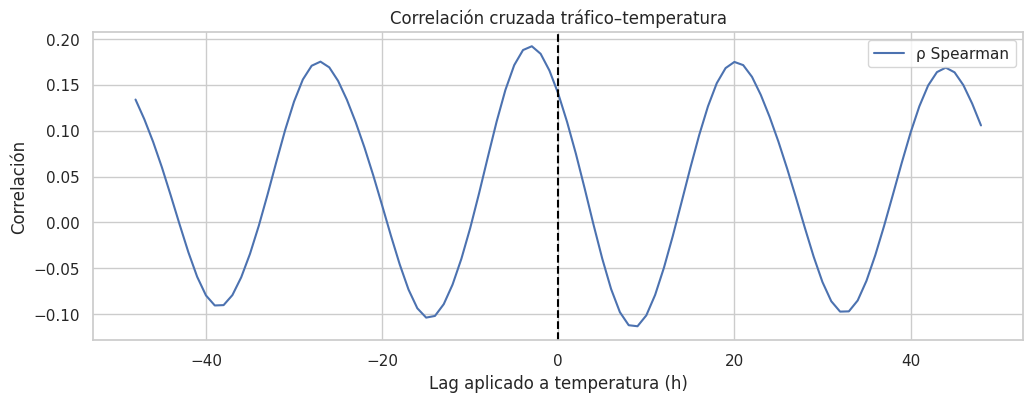

In [28]:
# Correlación cruzada con temperatura desplazada: explora precedencia.
lags=range(-48,49)
cc=[hourly_observed.y.corr(hourly_observed.temp.shift(l),method="spearman") for l in lags]
fig,ax=plt.subplots(); ax.plot(list(lags),cc,label="ρ Spearman")
ax.axvline(0,color="black",ls="--"); ax.set(title="Correlación cruzada tráfico–temperatura",xlabel="Lag aplicado a temperatura (h)",ylabel="Correlación"); ax.legend(); plt.show()

### 1.20 Weather main

Se exige tamaño mínimo para evitar categorías anecdóticas.

El filtro `count>=50` evita categorías anecdóticas; las diferencias de media entre condiciones existen pero son modestas.

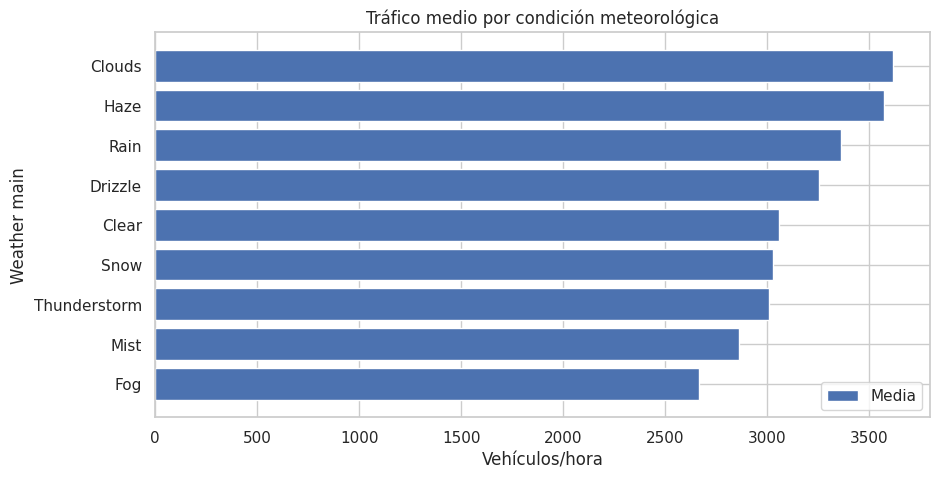

In [29]:
# Tráfico medio por condición meteorológica (mínimo 50 horas por categoría).
w=(hourly_observed.groupby("weather_main").y.agg(["mean","median","count"]).query("count>=50").sort_values("mean"))
fig,ax=plt.subplots(figsize=(10,5)); ax.barh(w.index,w["mean"],label="Media")
ax.set(title="Tráfico medio por condición meteorológica",xlabel="Vehículos/hora",ylabel="Weather main"); ax.legend(); plt.show()

### 1.21 Síntesis: ¿cuánto aportan las covariables?

Recapitulando la sección 1:

- Las correlaciones de Spearman con clima (1.18) son **débiles o moderadas** en comparación con la estacionalidad.
- La condición meteorológica (1.20) muestra diferencias de media entre categorías, pero el calendario confunde la lectura (ciertos climas son más frecuentes en ciertos meses).
- Las covariables climáticas observadas **no están disponibles como pronóstico** en producción: en despliegue habría que usar clima pronosticado.

Implicación para Semana 1: los baselines se construirán solo con calendario y valores pasados de `y`; las covariables se explorarán como features en semanas posteriores (Semana 3 y 4).

### 1.22 Festivos

Se compara distribución; hay muy pocas horas etiquetadas como festivo.

Casi todas las horas carecen de festivo; la comparación es limitada y debe leerse como exploratoria.

In [30]:
# Comparación de la distribución de y según la columna holiday.
h=hourly_observed.assign(is_holiday=lambda d:d.holiday.ne("None"))
summary_h=h.groupby("is_holiday").y.agg(["mean","median","count"])
summary_h

,mean,median,count
is_holiday,,,
True,3290.650474,3427.0,40575


## 2. Estrategia de validación

**Split requerido: 80/20 temporal.** El primer 80% entrena y el último 20% simula futuro. No se usa random split para estimar desempeño. El contraste aleatorio es exclusivamente didáctico.

### 2.1 Construcción del split

Se trabaja sobre timestamps observados únicos.

Se trabaja sobre timestamps observados únicos. El corte por posición sobre la serie ordenada por tiempo equivale aquí a una frontera temporal estricta.

In [31]:
# Split 80/20 temporal sobre timestamps observados (no aleatorio).
# El 80% inicial entrena; el 20% final simula el futuro.
series=hourly_observed[["y"]].copy(); cut=int(len(series)*.8)
train=series.iloc[:cut]; test=series.iloc[cut:]
# Verificación de la frontera temporal (train termina antes de test).
print(train.index.min(),train.index.max(),len(train)); print(test.index.min(),test.index.max(),len(test))

2012-10-02 09:00:00 2017-10-26 17:00:00 32460
2017-10-26 18:00:00 2018-09-30 23:00:00 8115


### 2.2 Diagrama temporal

El color deja explícita la frontera.

La línea discontinua marca la frontera temporal entre pasado (train) y futuro simulado (test).

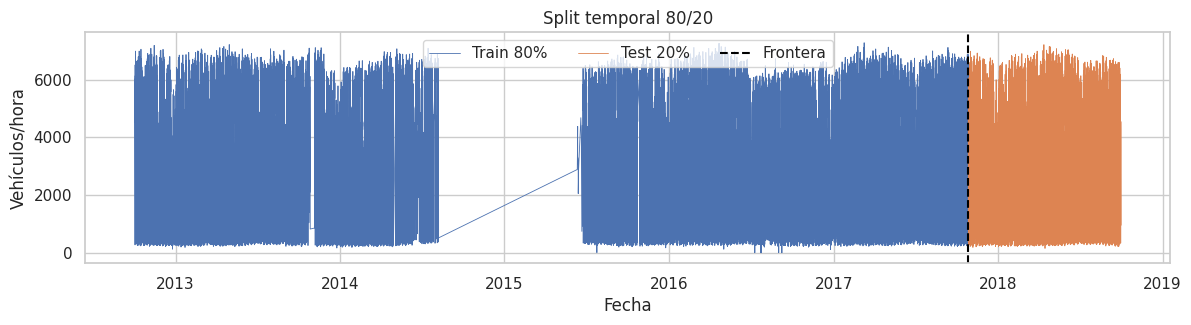

In [32]:
# Diagrama: train y test en el eje temporal, frontera explícita.
fig,ax=plt.subplots(figsize=(14,3)); ax.plot(train.index,train.y,label="Train 80%",lw=.6); ax.plot(test.index,test.y,label="Test 20%",lw=.6)
ax.axvline(test.index.min(),color="black",ls="--",label="Frontera"); ax.set(title="Split temporal 80/20",xlabel="Fecha",ylabel="Vehículos/hora"); ax.legend(ncol=3); plt.show()

### 2.3 Contraste didáctico: random split (anti-patrón de la semana)

> **Anti-patrón de la semana:** usar un *random split* para estimar el desempeño de un modelo de series temporales.

Un split aleatorio distribuye observaciones futuras en entrenamiento. Con features calendario, el modelo ve todo el periodo y la prueba deja de representar el despliegue. La métrica aleatoria no se usa para elegir el modelo final.

**El experimento como contraste controlado:** entrenamos el mismo Random Forest dos veces —una con split aleatorio y otra con split temporal— y comparamos. La sección 2.5 mostrará que el MAE aleatorio (≈251.7) es menor que el temporal (≈287.5); esa ventaja es ilusoria, porque el modelo aleatorio "vio" el futuro. La conclusión es explícita: en producción el error real se parecerá al temporal, no al aleatorio.

### 2.4 Dataset tabular del contraste

Se usan hora, día, mes y ordinal temporal. El ordinal vuelve visible el futuro filtrado.

In [33]:
# Dataset tabular con features de calendario + ordinal temporal.
tab=hourly_observed[["y"]].copy(); tab["hour"]=tab.index.hour; tab["dow"]=tab.index.dayofweek; tab["month"]=tab.index.month; tab["time_ordinal"]=(tab.index-tab.index.min()).total_seconds()/3600
X=tab.drop(columns="y"); y=tab.y
# ANTI-PATRÓN (didáctico): split aleatorio mezcla futuro en train.
X_tr_r,X_te_r,y_tr_r,y_te_r=train_test_split(X,y,test_size=.2,random_state=SEED,shuffle=True)
# Mismo modelo Random Forest para aislar el efecto del split.
model_r=RandomForestRegressor(n_estimators=60,max_depth=12,min_samples_leaf=5,n_jobs=-1,random_state=SEED).fit(X_tr_r,y_tr_r)
mae_random=mean_absolute_error(y_te_r,model_r.predict(X_te_r)); mae_random

251.65960148716465

### 2.5 Contraste temporal comparable

Misma clase de modelo, corte temporal.

Mismo Random Forest con corte temporal: el MAE es mayor que el aleatorio porque ya no hay futuro filtrado en train.

In [34]:
# Contraste: mismo modelo con corte temporal (80/20).
X_train_t,X_test_t=X.iloc[:cut],X.iloc[cut:]; y_train_t,y_test_t=y.iloc[:cut],y.iloc[cut:]
model_t=RandomForestRegressor(n_estimators=60,max_depth=12,min_samples_leaf=5,n_jobs=-1,random_state=SEED).fit(X_train_t,y_train_t)
mae_temporal=mean_absolute_error(y_test_t,model_t.predict(X_test_t))
# Tabla comparativa: el split aleatorio es artificialmente optimista.
pd.DataFrame({"split":["aleatorio (inválido)","temporal"],"MAE":[mae_random,mae_temporal]})

,split,MAE
0,aleatorio (inválido),251.659601
1,temporal,287.549525


### 2.6 Futuro filtrado

Los puntos rojos de train aparecen a lo largo de todo el calendario.

Los puntos de train del split aleatorio aparecen después de la frontera real: esa es la fuga de información.

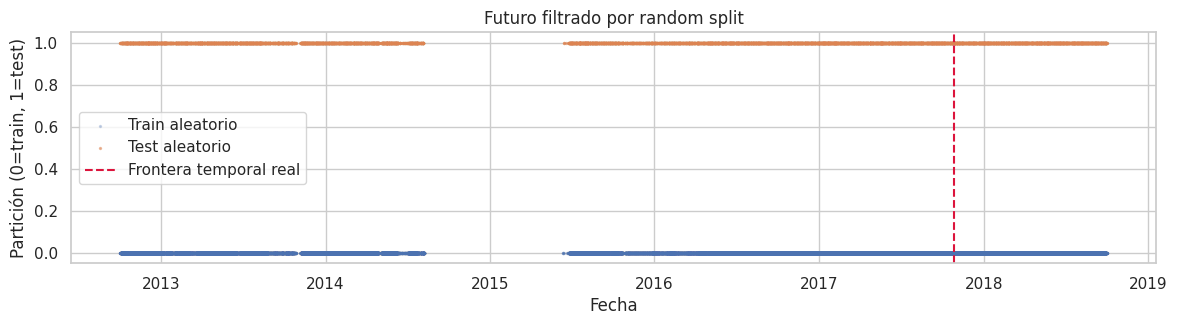

In [35]:
# Visualiza el futuro filtrado: el test aleatorio aparece en todo el calendario.
fig,ax=plt.subplots(figsize=(14,3)); idx_train=X_tr_r.index; idx_test=X_te_r.index
ax.scatter(idx_train,np.zeros(len(idx_train)),s=2,alpha=.25,label="Train aleatorio"); ax.scatter(idx_test,np.ones(len(idx_test)),s=2,alpha=.5,label="Test aleatorio")
ax.axvline(test.index.min(),color="crimson",ls="--",label="Frontera temporal real"); ax.set(title="Futuro filtrado por random split",xlabel="Fecha",ylabel="Partición (0=train, 1=test)"); ax.legend(); plt.show()

### Checkpoint de comprensión: split aleatorio vs. temporal

> **Pausa para pensar.** Antes de continuar, responda mentalmente:
> 1. ¿Qué pregunta responde el split aleatorio y qué pregunta responde el temporal?
> 2. ¿Por qué el MAE aleatorio (≈251.7) es menor que el temporal (≈287.5)?
> 3. En producción, ¿con cuál de los dos se parecerá más el error real?

**Conclusión explícita del anti-patrón.** El experimento demuestra que el random split *filtra futuro*: observaciones del test quedan dentro del train, el modelo "ve" todo el calendario y la métrica resulta artificialmente optimista. Por eso el split aleatorio se usa aquí **solo como contraste didáctico** y nunca para elegir el modelo final. La regla de oro: para estimar el desempeño en despliegue, validar siempre respetando el orden temporal.

## 3. Modelado

> **Methodology Card — Baselines**  
> **Pregunta:** ¿cuánto valor aporta cada complejidad sobre reglas simples?  
> **Horizonte:** todo el bloque test, evaluado en timestamps observados.  
> **Baselines:** naive, seasonal naive 168, medias 7/30/90 y ETS.  
> **Riesgo:** los gaps hacen que “168 filas” no siempre sean 168 horas; seasonal naive se alinea por timestamp.

### 3.1 Definiciones métricas

$$MAE=\frac{1}{n}\sum_{t=1}^{n}|y_t-\hat y_t|$$

$$RMSE=\sqrt{\frac{1}{n}\sum_{t=1}^{n}(y_t-\hat y_t)^2}$$

$$MASE=\frac{\frac{1}{n}\sum|y_t-\hat y_t|}{\frac{1}{T-m}\sum_{t=m+1}^{T}|y_t-y_{t-m}|},\;m=168$$

$$WAPE=\frac{\sum|y_t-\hat y_t|}{\sum|y_t|}	imes100$$

### 3.2 Funciones métricas

MASE se escala con train regular y lag semanal.

La escala MASE (≈399.1 veh/h) es el MAE del naive estacional sobre train; un MASE < 1 en test indica que el modelo supera esa referencia.

In [36]:
# Métricas estándar: MAE, RMSE, MASE y WAPE sobre el mismo test.
def metrics(y_true: pd.Series, y_pred: pd.Series, train_regular: pd.Series, m: int=168) -> dict[str,float]:
    a=pd.concat([y_true.rename("y"),y_pred.rename("p")],axis=1).dropna(); err=a.y-a.p
    # Escala MASE = MAE del naive estacional sobre train.
    scale=train_regular.diff(m).abs().dropna().mean()
    return {"MAE":float(err.abs().mean()),"RMSE":float(np.sqrt(np.mean(err**2))),"MASE":float(err.abs().mean()/scale),"WAPE_pct":float(100*err.abs().sum()/a.y.abs().sum())}
# Serie regular de train (solo para la escala MASE).
train_regular=hourly.loc[:train.index.max(),"y_eda"]
print("Escala MASE:",train_regular.diff(168).abs().dropna().mean())

Escala MASE: 399.1292963950343


In [37]:
# --- Constantes con nombre y funciones reutilizables -------------------------
# Valores canónicos del notebook: una semana en horas y el split 80/20.
SEASON_HOURS = 168          # ciclo semanal: 7 días × 24 horas
TEST_FRACTION = 0.2         # fracción final reservada como test temporal

def mae(y_true: pd.Series, y_pred: pd.Series) -> float:
    """Error absoluto medio, en las mismas unidades que y (vehículos/h)."""
    return float((y_true - y_pred).abs().mean())

def rmse(y_true: pd.Series, y_pred: pd.Series) -> float:
    """Raíz del error cuadrático medio: penaliza errores grandes."""
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def wape(y_true: pd.Series, y_pred: pd.Series) -> float:
    """Error porcentual absoluto ponderado (%)."""
    return float(100 * (y_true - y_pred).abs().sum() / y_true.abs().sum())

def mase(y_true: pd.Series, y_pred: pd.Series, train_regular: pd.Series, m: int = SEASON_HOURS) -> float:
    """MASE: MAE normalizado por el error del naive estacional sobre train."""
    scale = train_regular.diff(m).abs().dropna().mean()
    return float((y_true - y_pred).abs().mean() / scale)

def seasonal_naive_by_timestamp(series: pd.Series, test_index: pd.DatetimeIndex,
                                season: pd.Timedelta = pd.Timedelta(hours=SEASON_HOURS),
                                fallback: float | None = None) -> pd.Series:
    """Regla de negocio: pronóstico = valor observado en t - season (misma hora, semana previa).

    Política de fallback: si el timestamp no existe (gap), se usa el último
    valor observado de la serie. La alineación es por timestamp, nunca por fila.
    """
    lookup = series
    preds = pd.Series([lookup.get(t - season, np.nan) for t in test_index], index=test_index)
    if fallback is None:
        fallback = series.iloc[-1]
    return preds.fillna(fallback)

def temporal_split(series: pd.Series, fraction: float = TEST_FRACTION, embargo: int = 0):
    """Split temporal (1 - fraction) / fraction con embargo opcional.

    - embargo=0: igual al split del notebook (80/20 por tiempo).
    - embargo>0: descarta las últimas 'embargo' observaciones del train
      (período de enfriamiento antes de la frontera temporal).
    """
    n = len(series)
    cut = int(n * (1 - fraction))
    train = series.iloc[: max(0, cut - embargo)]
    test = series.iloc[cut:]
    # Aserciones anti-leakage: bloques no vacíos y frontera temporal estricta.
    assert len(train) > 0 and len(test) > 0, "Bloques train/test vacíos"
    assert train.index.max() < test.index.min(), "Fuga temporal: train y test se solapan"
    return train, test

# Autocomprobación rápida de las utilidades (no altera celdas posteriores).
_s = pd.Series([100.0, 110.0, 105.0, 120.0], index=pd.date_range("2017-01-01", periods=4, freq="h"))
assert abs(mae(_s, _s + 5) - 5.0) < 1e-9
_tr, _te = temporal_split(hourly_observed["y"])
print(f"Constantes: SEASON_HOURS={SEASON_HOURS}, TEST_FRACTION={TEST_FRACTION}")
print(f"Split temporal OK: train={len(_tr)} filas ({_tr.index.min()} -> {_tr.index.max()}), test={len(_te)} filas")

Constantes: SEASON_HOURS=168, TEST_FRACTION=0.2
Split temporal OK: train=32460 filas (2012-10-02 09:00:00 -> 2017-10-26 17:00:00), test=8115 filas


### 3.3 Naive

Pronóstico constante igual a la última observación de train.

Naive: pronóstico constante igual a la última observación; es el baseline más simple y su error sirve de referencia superior.

In [38]:
# Contenedor común de predicciones (mismo índice test).
# Naive: constante = última observación de train.
preds=pd.DataFrame(index=test.index); preds["Naive"]=train.y.iloc[-1]
metrics(test.y,preds.Naive,train_regular)

{'MAE': 3101.346395563771,
 'RMSE': 3660.7483789889015,
 'MASE': 7.770280015963157,
 'WAPE_pct': 93.70865408806812}

### 3.4 Seasonal naive 168

**Regla de negocio.** El pronóstico de esta semana es "lo que ocurrió la misma hora de la semana pasada": una regla que cualquier operador de tráfico puede explicar sin estadística.

- **Supuesto:** el patrón semanal es estable (típico del tráfico urbano: mismos picos laborales, mismo descenso de fin de semana).
- **Ventaja:** simple, interpretable, sin covariables y sin entrenamiento; sirve como piso productivo.
- **Cuándo falla:** festivos, incidentes, clima extremo o cambios estructurales que rompen la semana.

**Riesgo clave — 168 filas ≠ 168 horas.** Este dataset tiene gaps: la fila *i*-ésima no corresponde necesariamente a la hora *i*-ésima. Por eso el código busca el **timestamp** exacto `t − 168 h` (lookup por índice temporal), en lugar de asumir que el valor está 168 filas atrás. Un `shift(168)` ingenuo sobre la serie con gaps alinearía mal el pronóstico.

**Interpretación del resultado (celda siguiente):** MAE ≈ 365.7 veh/h, MASE ≈ 0.92 (< 1, supera la escala del naive estacional de train ≈ 399.1) y WAPE ≈ 11.0% del tráfico real. El RMSE (≈ 734.6) muy por encima del MAE indica errores grandes en horas pico.

In [39]:
# Valores observados para buscar por timestamp.
lookup=hourly_observed.y
# Riesgo clave: alinear por timestamp (t−168 h), NO por posición de fila.
preds["SeasonalNaive168"]=[lookup.get(t-pd.Timedelta(hours=168),np.nan) for t in test.index]
# Fallback: si falta el valor de hace una semana, se usa el último observado.
preds["SeasonalNaive168"]=preds["SeasonalNaive168"].fillna(train.y.iloc[-1])
metrics(test.y,preds.SeasonalNaive168,train_regular)

{'MAE': 365.6800985828712,
 'RMSE': 734.5901403550413,
 'MASE': 0.9161945812690806,
 'WAPE_pct': 11.04919783033901}

### 3.5 Moving average 7

Forecast constante con las últimas 7 observaciones.

MA7 suaviza la última semana; al ser constante pierde el ciclo intradiario.

In [40]:
# Media móvil 7: constante = promedio de la última semana observada.
preds["MA7"]=train.y.tail(7).mean(); metrics(test.y,preds.MA7,train_regular)

{'MAE': 2529.78132206672,
 'RMSE': 3125.8331601233745,
 'MASE': 6.338250148300047,
 'WAPE_pct': 76.43854397145215}

### 3.6 Moving average 30

Forecast constante con las últimas 30 observaciones.

MA30 promedia las últimas ~4 semanas; más suave, pero sigue ignorando el patrón horario.

In [41]:
# Media móvil 30: promedio de las últimas ~4 semanas.
preds["MA30"]=train.y.tail(30).mean(); metrics(test.y,preds.MA30,train_regular)

{'MAE': 1776.2784966112138,
 'RMSE': 2160.388810308625,
 'MASE': 4.450383654256138,
 'WAPE_pct': 53.671098282059425}

### 3.7 Moving average 90

Forecast constante con las últimas 90 observaciones.

MA90 promedia las últimas ~13 semanas: en la práctica es una constante de nivel.

In [42]:
# Media móvil 90: promedio de las últimas ~13 semanas (más suavizada).
preds["MA90"]=train.y.tail(90).mean(); metrics(test.y,preds.MA90,train_regular)

{'MAE': 1731.8235859519407,
 'RMSE': 2030.1444516440138,
 'MASE': 4.339003930791102,
 'WAPE_pct': 52.327872046046366}

### 3.8 Exponential Smoothing

Para CPU, ETS se ajusta sobre las últimas 52 semanas de la serie regular. Conserva tendencia amortiguada y estacionalidad semanal.

ETS captura tendencia y estacionalidad semanal; el recorte a 52 semanas controla el costo computacional.

In [43]:
# ETS sobre las últimas 52 semanas de la serie regular (CPU).
ets_train=train_regular.tail(24*7*52)
# Tendencia amortiguada + estacionalidad semanal (168).
ets=ExponentialSmoothing(ets_train,trend="add",damped_trend=True,seasonal="add",seasonal_periods=168,initialization_method="estimated").fit(optimized=True,use_brute=False)
regular_future=pd.date_range(train.index.max()+pd.Timedelta(hours=1),test.index.max(),freq="h")
ets_regular=pd.Series(ets.forecast(len(regular_future)),index=regular_future)
# Reindexado a los timestamps observados del test.
preds["ETS"]=ets_regular.reindex(test.index).interpolate().ffill().bfill().values
metrics(test.y,preds.ETS,train_regular)

{'MAE': 785.2296471752013,
 'RMSE': 950.3786038259306,
 'MASE': 1.9673565791021963,
 'WAPE_pct': 23.726086673868828}

### 3.9 Tabla comparativa

Todas las métricas usan el mismo conjunto test.

La tabla ordena por MASE: Seasonal Naive 168 lidera con holgura (0.92 vs. 1.97 de ETS).

> **Lectura operativa:** el Seasonal Naive 168 ya produce un error medio (MAE) de ~365.7 vehículos/hora. Cualquier modelo que se proponga a futuro debe mejorar *mediblemente* esa cifra para justificar su complejidad adicional — no basta con acercarse; hay que superarla bajo el mismo protocolo de test. Ese error, sostenido en hora pico, es el margen de holgura que la autoridad vial pierde para anticipar congestión antes de que ocurra.

In [44]:
# Ranking de baselines por MASE (menor = mejor).
score_table=pd.DataFrame({name:metrics(test.y,preds[name],train_regular) for name in preds}).T.sort_values("MASE")
score_table

,MAE,RMSE,MASE,WAPE_pct
SeasonalNaive168,365.680099,734.590140,0.916195,11.049198
ETS,785.229647,950.378604,1.967357,23.726087
MA90,1731.823586,2030.144452,4.339004,52.327872
MA30,1776.278497,2160.388810,4.450384,53.671098
MA7,2529.781322,3125.833160,6.338250,76.438544
Naive,3101.346396,3660.748379,7.770280,93.708654


### 3.10 Ranking visual

Menor MASE es mejor; MASE < 1 supera el seasonal naive de escala en promedio.

MASE < 1 indica que el baseline supera en promedio al naive estacional de escala.

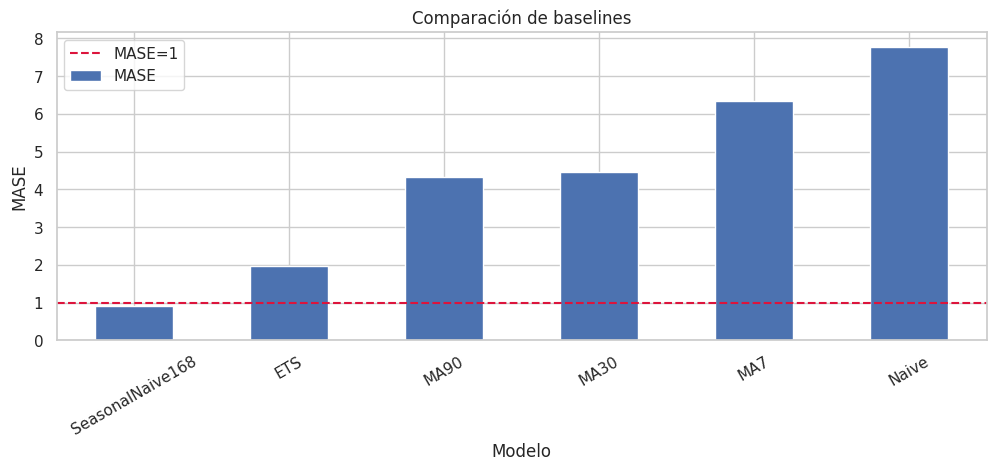

In [45]:
# Gráfico de barras del ranking MASE con referencia MASE=1.
fig,ax=plt.subplots(); score_table.MASE.sort_values().plot.bar(ax=ax,label="MASE")
ax.axhline(1,color="crimson",ls="--",label="MASE=1"); ax.set(title="Comparación de baselines",xlabel="Modelo",ylabel="MASE"); ax.legend(); plt.xticks(rotation=30); plt.show()

### 3.11 Forecast: zoom

Se muestran las primeras dos semanas del test.

El zoom de dos semanas muestra cómo Seasonal Naive 168 sigue el patrón real casi sin desfase.

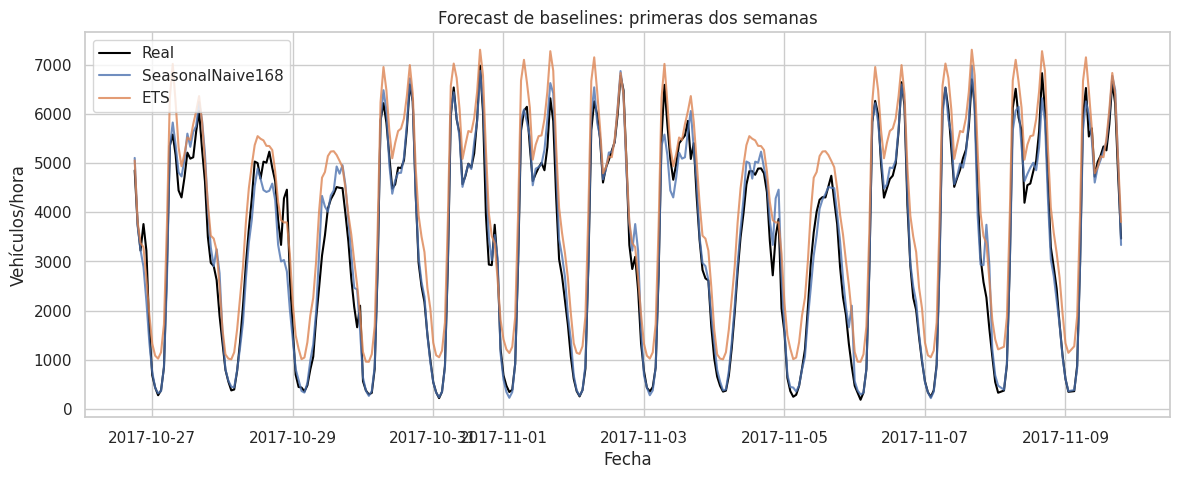

In [46]:
# Zoom: primeras dos semanas del test para comparar visualmente.
zoom=test.index[:24*14]; fig,ax=plt.subplots(figsize=(14,5)); ax.plot(test.loc[zoom].index,test.loc[zoom,"y"],label="Real",color="black")
for name in ["SeasonalNaive168","ETS"]: ax.plot(zoom,preds.loc[zoom,name],label=name,alpha=.8)
ax.set(title="Forecast de baselines: primeras dos semanas",xlabel="Fecha",ylabel="Vehículos/hora"); ax.legend(); plt.show()

### 3.12 Bandas simples

Se usa ±1.96·desviación robusta de errores train one-step del seasonal naive. Es una banda heurística, no un intervalo probabilístico calibrado.

La banda es una heurística de incertidumbre, no un intervalo calibrado; los tests de la sección 4 lo confirmarán.

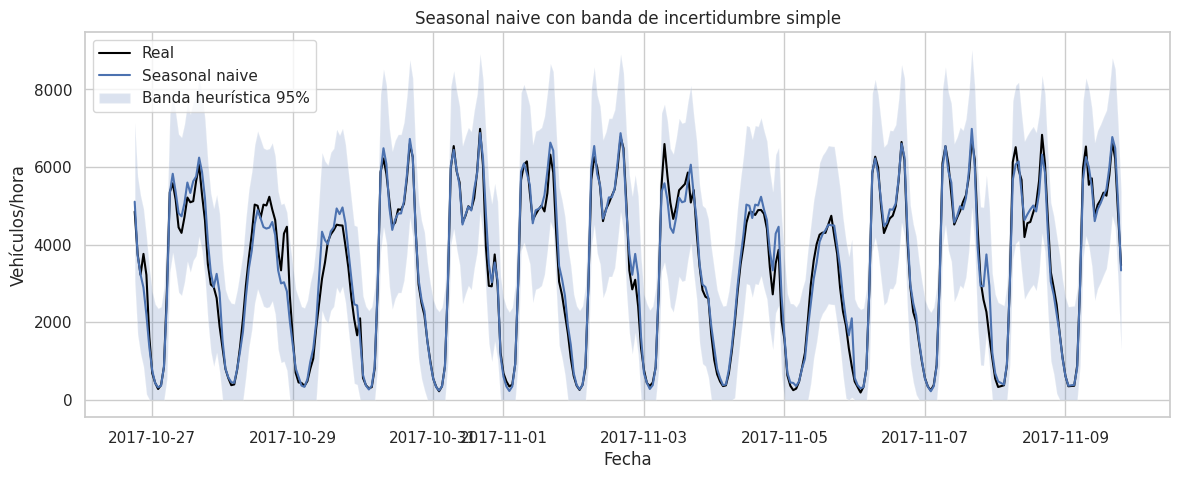

In [47]:
# Errores one-step del seasonal naive en train (heurística de banda).
# Desviación robusta (MAD) para acotar la banda.
train_sn=train.y.shift(168); err_train=(train.y-train_sn).dropna(); sigma=1.4826*np.median(np.abs(err_train-np.median(err_train)))
# Banda heurística ±1.96σ, truncada en 0 (sin tráfico negativo).
center=preds["SeasonalNaive168"]; lower=(center-1.96*sigma).clip(lower=0); upper=center+1.96*sigma
zoom=test.index[:24*14]; fig,ax=plt.subplots(figsize=(14,5)); ax.plot(zoom,test.loc[zoom,"y"],label="Real",color="black"); ax.plot(zoom,center.loc[zoom],label="Seasonal naive")
ax.fill_between(zoom,lower.loc[zoom],upper.loc[zoom],alpha=.2,label="Banda heurística 95%")
ax.set(title="Seasonal naive con banda de incertidumbre simple",xlabel="Fecha",ylabel="Vehículos/hora"); ax.legend(); plt.show()

## 4. Análisis posterior (post-modeling)

Los diagnósticos se aplican al baseline con menor MASE. En baselines no paramétricos, normalidad no es requisito para el punto forecast, pero importa para bandas gaussianas.

### 4.1 Selección reproducible

Se escoge por MASE exclusivamente en esta comparación didáctica.

In [48]:
# Selección reproducible del baseline con menor MASE.
best_name=score_table.index[0]; best_pred=preds[best_name]; residuals=(test.y-best_pred).dropna()
print("Mejor baseline:",best_name,"n residuos:",len(residuals))

Mejor baseline: SeasonalNaive168 n residuos: 8115


### 4.2 Serie de residuos

Se busca sesgo y estructura temporal.

Los residuos del mejor baseline deberían parecer ruido; si muestran estructura, queda señal sin modelar.

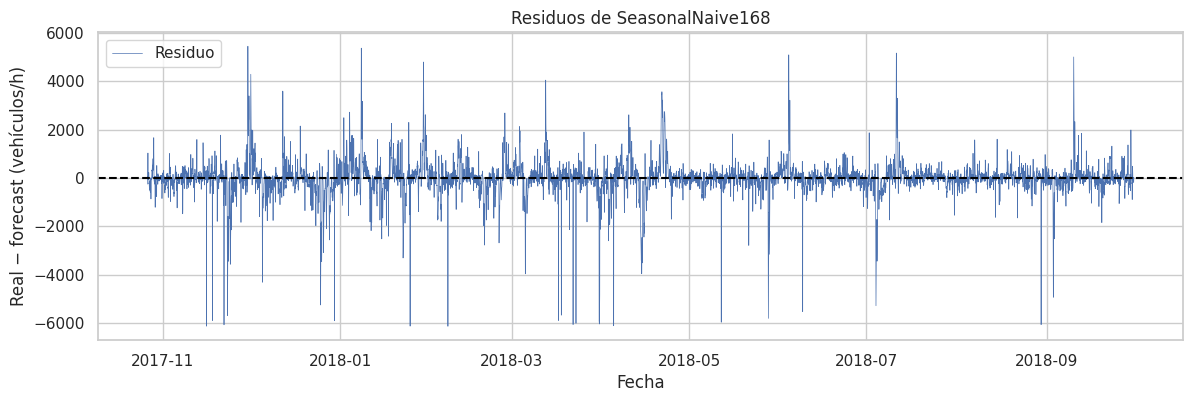

In [49]:
# Serie de residuos: busca sesgo sistemático y estructura temporal.
fig,ax=plt.subplots(figsize=(14,4)); ax.plot(residuals.index,residuals,lw=.5,label="Residuo")
ax.axhline(0,color="black",ls="--"); ax.set(title=f"Residuos de {best_name}",xlabel="Fecha",ylabel="Real − forecast (vehículos/h)"); ax.legend(); plt.show()

### 4.3 Ljung–Box

H₀: no hay autocorrelación conjunta hasta el lag indicado. α=0.05.

Ljung–Box rechaza la hipótesis nula: los residuos conservan autocorrelación.

In [50]:
# Ljung–Box: autocorrelación conjunta en lags 24 y 168.
lb=acorr_ljungbox(residuals,lags=[24,168],return_df=True).rename(columns={"lb_stat":"estadistico","lb_pvalue":"p_value"})
lb["decision_alpha_0.05"]=np.where(lb.p_value<.05,"rechazar H0","no rechazar H0"); lb

,estadistico,p_value,decision_alpha_0.05
24,19574.858422,0.0,rechazar H0
168,30021.438985,0.0,rechazar H0


### 4.4 Jarque–Bera

H₀: normalidad basada en asimetría y curtosis. En n grande detecta desviaciones pequeñas.

Jarque–Bera rechaza normalidad: la banda gaussiana de la sección 3.12 es solo aproximada.

In [51]:
# Jarque–Bera: asimetría y curtosis de los residuos.
jb_stat,jb_p,skew,kurt=jarque_bera(residuals)
pd.DataFrame([{"test":"Jarque-Bera","H0":"normalidad","stat":jb_stat,"p_value":jb_p,"decision":"rechazar H0" if jb_p<.05 else "no rechazar H0","skew":skew,"kurtosis":kurt}])

,test,H0,stat,p_value,decision,skew,kurtosis
0,Jarque-Bera,normalidad,148993.138199,0.0,rechazar H0,-1.181525,23.858119


### 4.5 QQ-plot

Desviaciones en colas cuestionan bandas gaussianas.

El QQ-plot muestra colas pesadas: otra razón para no confiar en bandas normales.

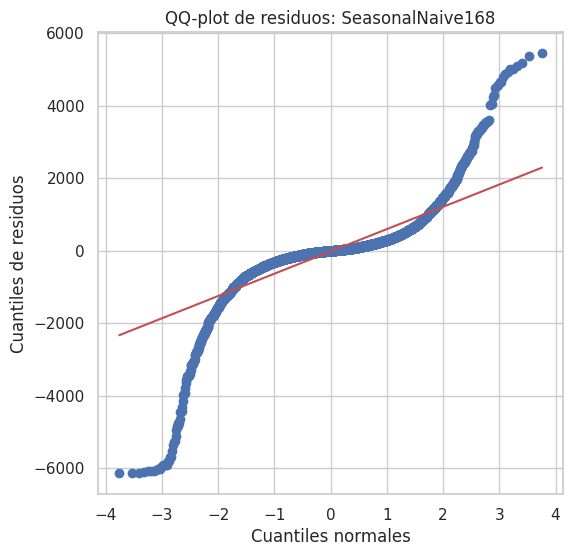

In [52]:
# QQ-plot: compara cuantiles empíricos vs. normales.
fig,ax=plt.subplots(figsize=(6,6)); stats.probplot(residuals,dist="norm",plot=ax); ax.set(title=f"QQ-plot de residuos: {best_name}",xlabel="Cuantiles normales",ylabel="Cuantiles de residuos"); plt.show()

### 4.6 ARCH LM

H₀: no hay heterocedasticidad ARCH hasta 24 lags.

ARCH LM detecta heterocedasticidad: el error no es constante a lo largo del tiempo.

In [53]:
# ARCH LM: heterocedasticidad condicional en los residuos.
arch_stat,arch_p,_,_=het_arch(residuals,nlags=24)
pd.DataFrame([{"test":"ARCH LM","H0":"homocedasticidad condicional","stat":arch_stat,"p_value":arch_p,"decision":"rechazar H0" if arch_p<.05 else "no rechazar H0"}])

,test,H0,stat,p_value,decision
0,ARCH LM,homocedasticidad condicional,2670.804578,0.0,rechazar H0


### 4.7 Error por horizonte

Se define horizonte como hora dentro de cada bloque semanal de 168.

El MAE por horizonte muestra cómo varía el error según la posición dentro de la semana.

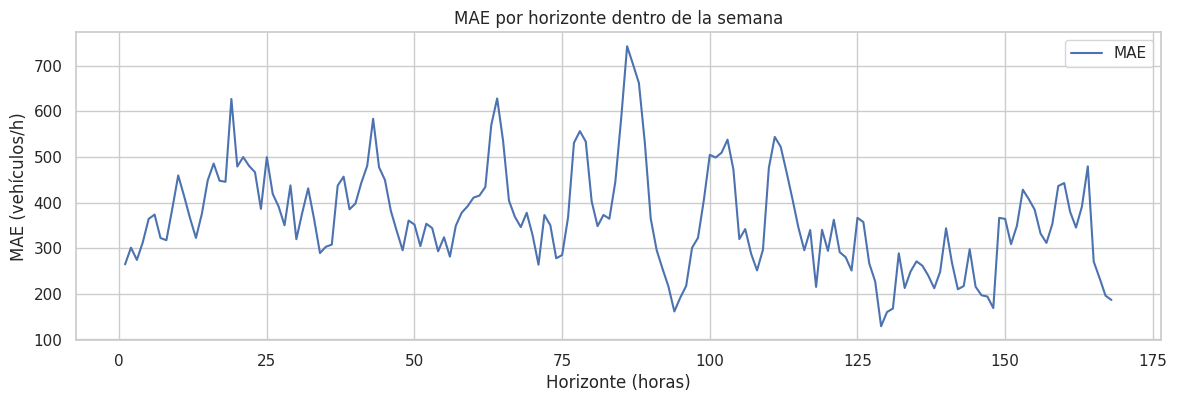

In [54]:
# Error por horizonte dentro de la semana (posición 1–168).
err=pd.DataFrame({"abs_error":residuals.abs(),"horizon_in_week":np.arange(len(residuals))%168+1})
by_h=err.groupby("horizon_in_week").abs_error.mean(); fig,ax=plt.subplots(figsize=(14,4)); ax.plot(by_h.index,by_h,label="MAE")
ax.set(title="MAE por horizonte dentro de la semana",xlabel="Horizonte (horas)",ylabel="MAE (vehículos/h)"); ax.legend(); plt.show()

### 4.8 Error por hora

Segmentación operativa de picos y valles.

El error por hora identifica las franjas críticas (picos) donde un error tiene mayor costo operativo.

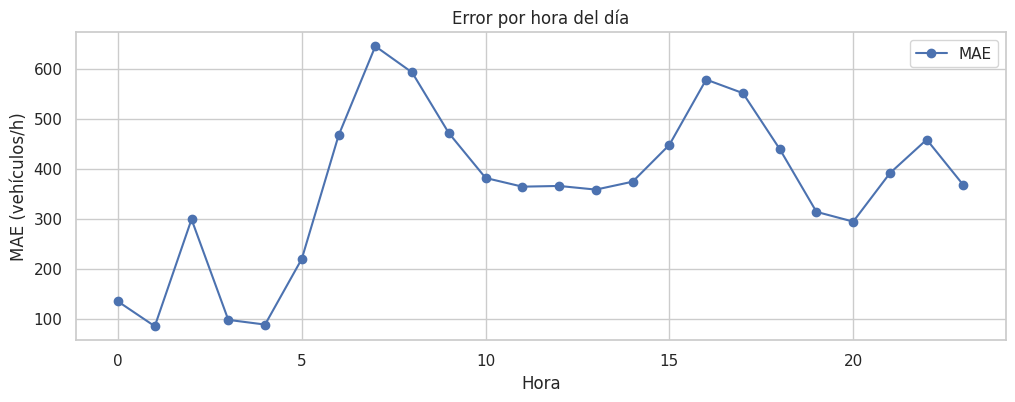

In [55]:
# Error por hora del día: franjas operativas con mayor riesgo.
seg=pd.DataFrame({"abs_error":residuals.abs(),"hour":residuals.index.hour})
fig,ax=plt.subplots(); seg.groupby("hour").abs_error.mean().plot(ax=ax,marker="o",label="MAE")
ax.set(title="Error por hora del día",xlabel="Hora",ylabel="MAE (vehículos/h)"); ax.legend(); plt.show()

## 5. Lecciones metodológicas

1. El dataset no es una rejilla horaria perfecta: consolidar duplicados y declarar gaps es parte del modelado.  
2. La estacionalidad diaria/semanal domina; un baseline estacional es difícil de superar.  
3. Random split mezcla futuro en train y responde una pregunta distinta del despliegue.  
4. Correlación meteorológica no demuestra causalidad ni disponibilidad futura.  
5. Bandas gaussianas simples fallan si residuos tienen autocorrelación, colas o heterocedasticidad.  

**Conexión con Semana 2:** Box–Jenkins intentará modelar explícitamente la dependencia que permanece en residuos.

## 6. Ejercicios propuestos

1. **Fácil:** compare seasonal naive de 24 y 168 horas con el mismo test.  
2. **Intermedio:** construya intervalos por cuantiles empíricos de error condicionados a hora del día.  
3. **Intermedio:** elimine duplicados con otra regla y mida sensibilidad de resultados.  
4. **Difícil:** cree un modelo de regresión con feriados y clima pronosticado, no observado.  
5. **Difícil:** implemente rolling-origin mensual y reporte distribución de MASE.

### Decisión ejecutiva

Con los resultados de este notebook (Seasonal Naive 168: MASE ≈ 0.92 y WAPE ≈ 11.0% sobre el test temporal):

1. **Adoptar Seasonal Naive 168 como piso productivo.** Ningún modelo más complejo se desplegará sin superar este baseline en el mismo test temporal (mismas métricas y misma frontera).
2. **Monitorear el error por franja crítica.** La sección 4.8 muestra el MAE por hora del día: las horas pico concentran el mayor volumen y, por el costo asimétrico del caso de negocio, el mayor riesgo. Cualquier mejora debe priorizarse ahí.
3. **Mantener la validación temporal.** La decisión de negocio se apoya en el split 80/20 temporal; el random split queda descartado como herramienta de estimación (sección 2).

### Checklist de reproducibilidad

- [ ] Ejecutar el notebook de arriba hacia abajo, sin reordenar celdas.
- [ ] Fijar la seed global (SEED = 42) antes de cualquier muestreo.
- [ ] Verificar el contrato: 48,204 filas × 9 columnas y referencia a `data/01_traffic_metro/traffic.csv`.
- [ ] Confirmar las aserciones post-split: `train.ds.max() < test.ds.min()` y bloques no vacíos.
- [ ] Alinear los baselines por timestamp (no por posición de fila) para respetar los gaps.
- [ ] Reportar MAE, RMSE, MASE y WAPE sobre el mismo conjunto test.
- [ ] Comparar todo modelo nuevo contra Seasonal Naive 168 (MASE y WAPE).

In [56]:
# Cierre: confirma que la ejecución llegó al final.
print("Notebook 1 completado.")
print("Celdas ejecutadas sobre:", DATA_PATH.resolve())
print("Mejor baseline por MASE:", best_name)

Notebook 1 completado.
Celdas ejecutadas sobre: /home/enrique/Escritorio/Curso_pronostico_series_temporales/course-timeseries-benchmarks-pro/data/01_traffic_metro/traffic.csv
Mejor baseline por MASE: SeasonalNaive168
